<a href="https://colab.research.google.com/github/KudjoJedidiah/beginner_projects/blob/main/Insurance_Prediction_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path='/content/drive/MyDrive/Zindi/Insurance/train_data.csv'
path2='/content/drive/MyDrive/Zindi/Insurance/test_data.csv'

In [3]:
import pandas as pd


In [4]:
train=pd.read_csv(path)
test = pd.read_csv(path2)

In [5]:
train.head()

,Customer Id,YearOfObservation,Insured_Period,Residential,Building_Painted,Building_Fenced,Garden,Settlement,Building Dimension,Building_Type,Date_of_Occupancy,NumberOfWindows,Geo_Code,Claim
0,H14663,2013,1.0,0,N,V,V,U,290.0,1,1960.0,.,1053,0
1,H2037,2015,1.0,0,V,N,O,R,490.0,1,1850.0,4,1053,0
2,H3802,2014,1.0,0,N,V,V,U,595.0,1,1960.0,.,1053,0
3,H3834,2013,1.0,0,V,V,V,U,2840.0,1,1960.0,.,1053,0
4,H5053,2014,1.0,0,V,N,O,R,680.0,1,1800.0,3,1053,0


In [6]:
print(f"Number of columns and rows: {train.shape}")
print(f"Number of columns and rows: {train.info()}")


Number of columns and rows: (7160, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         7160 non-null   object 
 1   YearOfObservation   7160 non-null   int64  
 2   Insured_Period      7160 non-null   float64
 3   Residential         7160 non-null   int64  
 4   Building_Painted    7160 non-null   object 
 5   Building_Fenced     7160 non-null   object 
 6   Garden              7153 non-null   object 
 7   Settlement          7160 non-null   object 
 8   Building Dimension  7054 non-null   float64
 9   Building_Type       7160 non-null   int64  
 10  Date_of_Occupancy   6652 non-null   float64
 11  NumberOfWindows     7160 non-null   object 
 12  Geo_Code            7058 non-null   object 
 13  Claim               7160 non-null   int64  
dtypes: float64(3), int64(4), object(7)
memory usage: 783.3+ KB
Number

In [7]:
train.value_counts('Claim',normalize=True)

,proportion
Claim,
0,0.771788
1,0.228212


The data is moderately imbalanced,about 1 in every 4 to 5 buildings had a claim.Since this competition evaluates on AUC,we don't need to balance classes with penalties

In [8]:
train['Building_Painted'].value_counts(dropna=False)

,count
Building_Painted,
V,5382
N,1778


In [9]:
train['Building_Fenced'].value_counts(dropna=False)

,count
Building_Fenced,
N,3608
V,3552


In [10]:
train['Garden'].value_counts(dropna=False)

,count
Garden,
O,3602
V,3551
NaN,7


In [11]:
train['NumberOfWindows'].value_counts(dropna=False)

,count
NumberOfWindows,
.,3551
4,939
3,844
5,639
2,363
6,306
7,211
8,116
1,75


In [12]:
train.groupby('Building_Painted')['Claim'].value_counts(normalize=True)


Building_Painted  Claim
N                 0        0.793588
                  1        0.206412
V                 0        0.764586
                  1        0.235414
Name: proportion, dtype: float64

In [13]:
train.groupby('Building_Fenced')['Claim'].value_counts(normalize=True)

Building_Fenced  Claim
N                0        0.750277
                 1        0.249723
V                0        0.793637
                 1        0.206363
Name: proportion, dtype: float64

In [14]:
train.groupby('Garden')['Claim'].value_counts(normalize=True)

Garden  Claim
O       0        0.750139
        1        0.249861
V       0        0.793861
        1        0.206139
Name: proportion, dtype: float64

It can been seen that ;
for builing_painted:
Painted:23.5% claim rate
NonPainted:20.6% claim rate
Takeaway: Painted buildings are slightly more likely to file a claim.

building_fenced:
Fenced:25% claim rate       
Nonfenced:20.6% claim rate
Takeaway: Unfenced buildings have a higher claim rate.


Garden:
No Garden:25% claim rate    
Has Garden:20.6% claim rate
Takeaway: Buildings without a garden have a higher claim rate


In [15]:
print(f'{train['Building Dimension'].describe()}')
print(f'{train['Insured_Period'].describe()}')
print(f'{train['Date_of_Occupancy'].describe()}')

count     7054.000000
mean      1883.727530
std       2278.157745
min          1.000000
25%        528.000000
50%       1083.000000
75%       2289.750000
max      20940.000000
Name: Building Dimension, dtype: float64
count    7160.000000
mean        0.909758
std         0.239756
min         0.000000
25%         0.997268
50%         1.000000
75%         1.000000
max         1.000000
Name: Insured_Period, dtype: float64
count    6652.000000
mean     1964.456404
std        36.002014
min      1545.000000
25%      1960.000000
50%      1970.000000
75%      1980.000000
max      2016.000000
Name: Date_of_Occupancy, dtype: float64


In [16]:
print(f'Missing entries for building dim:{train['Building Dimension'].isnull().sum()}')
print(f'Missing entries for insurance per:{train['Insured_Period'].isnull().sum()}')
print(f'Missing entries for date_of_occ:{train['Date_of_Occupancy'].isnull().sum()}')

Missing entries for building dim:106
Missing entries for insurance per:0
Missing entries for date_of_occ:508


In [17]:
print(train.groupby('Claim')['Building Dimension'].mean())
print(train.groupby('Claim')['Building Dimension'].median())

Claim
0    1514.948152
1    3125.703406
Name: Building Dimension, dtype: float64
Claim
0     900.0
1    2000.0
Name: Building Dimension, dtype: float64


Larger buildings are likely to file insurance claims

Newer buildings tend to slightly file for claims

In [18]:
train.groupby('Settlement')['Claim'].mean()


,Claim
Settlement,
R,0.249861
U,0.206197


Rural buildings have a slightly higher chance of filing a claim compared to urban

In [19]:
train.groupby('Building_Type')['Claim'].mean()

,Claim
Building_Type,
1,0.177156
2,0.215431
3,0.252846
4,0.337734


As the building type increases from 1 to 4,the likelihood of a claim almost doubles.

In [20]:
train.groupby('Building_Painted')['Claim'].mean()

,Claim
Building_Painted,
N,0.206412
V,0.235414


Painted buildings have a higher chance of filing for claim as compared to the non-painted

In [21]:
train.groupby('NumberOfWindows')['Claim'].mean()

,Claim
NumberOfWindows,
.,0.206139
1,0.093333
2,0.110193
3,0.155213
4,0.236422
5,0.300469
6,0.343137
7,0.426540
8,0.474138


In [22]:
train.groupby('Geo_Code')['Claim'].mean()

,Claim
Geo_Code,
10033,0.000000
10081,0.000000
10297,0.000000
10333,0.000000
10343,0.000000
...,...
95563,0.000000
95582,0.333333
95585,0.428571


In [23]:
train['Building Dimension'].fillna(train['Building Dimension'].mean(),inplace=True)
train['Insured_Period'].fillna(train['Insured_Period'].mean(),inplace=True)
train['Date_of_Occupancy'].fillna(train['Date_of_Occupancy'].mean(),inplace=True)

/tmp/ipykernel_4928/1740253574.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Building Dimension'].fillna(train['Building Dimension'].mean(),inplace=True)
/tmp/ipykernel_4928/1740253574.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [24]:
print(f'Missing entries for building dim:{train['Building Dimension'].isnull().sum()}')
print(f'Missing entries for insurance per:{train['Insured_Period'].isnull().sum()}')
print(f'Missing entries for date_of_occ:{train['Date_of_Occupancy'].isnull().sum()}')

Missing entries for building dim:0
Missing entries for insurance per:0
Missing entries for date_of_occ:0


In [25]:
train['Age']=train['YearOfObservation']-train['Date_of_Occupancy']
print(train)

     Customer Id  YearOfObservation  Insured_Period  Residential  \
0         H14663               2013        1.000000            0   
1          H2037               2015        1.000000            0   
2          H3802               2014        1.000000            0   
3          H3834               2013        1.000000            0   
4          H5053               2014        1.000000            0   
...          ...                ...             ...          ...   
7155       H5290               2012        1.000000            1   
7156       H5926               2013        1.000000            0   
7157       H6204               2016        0.038251            0   
7158       H6537               2013        1.000000            0   
7159       H7470               2014        1.000000            0   

     Building_Painted Building_Fenced Garden Settlement  Building Dimension  \
0                   N               V      V          U           290.00000   
1                   V    

In [26]:
print(train.groupby('Claim')['Age'].mean())
print(train.groupby('Claim')['Age'].median())

Claim
0    49.575226
1    47.988646
Name: Age, dtype: float64
Claim
0    48.543596
1    45.000000
Name: Age, dtype: float64


In [27]:
train['Garden'].fillna(train['Garden'].mode()[0],inplace=True)
train['Geo_Code'].fillna('Missing',inplace=True)

/tmp/ipykernel_4928/2059308029.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Garden'].fillna(train['Garden'].mode()[0],inplace=True)
/tmp/ipykernel_4928/2059308029.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [28]:
train.isnull().sum()

,0
Customer Id,0
YearOfObservation,0
Insured_Period,0
Residential,0
Building_Painted,0
Building_Fenced,0
Garden,0
Settlement,0
Building Dimension,0
Building_Type,0


In [29]:
train.isnull().sum()

,0
Customer Id,0
YearOfObservation,0
Insured_Period,0
Residential,0
Building_Painted,0
Building_Fenced,0
Garden,0
Settlement,0
Building Dimension,0
Building_Type,0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         7160 non-null   object 
 1   YearOfObservation   7160 non-null   int64  
 2   Insured_Period      7160 non-null   float64
 3   Residential         7160 non-null   int64  
 4   Building_Painted    7160 non-null   object 
 5   Building_Fenced     7160 non-null   object 
 6   Garden              7160 non-null   object 
 7   Settlement          7160 non-null   object 
 8   Building Dimension  7160 non-null   float64
 9   Building_Type       7160 non-null   int64  
 10  Date_of_Occupancy   7160 non-null   float64
 11  NumberOfWindows     7160 non-null   object 
 12  Geo_Code            7160 non-null   object 
 13  Claim               7160 non-null   int64  
 14  Age                 7160 non-null   float64
dtypes: float64(4), int64(4), object(7)
memory usage: 839.2+

In [31]:
train=pd.get_dummies(train,columns=['Building_Painted','Building_Fenced','Garden','Settlement'],drop_first=True)

In [32]:
train

,Customer Id,YearOfObservation,Insured_Period,Residential,Building Dimension,Building_Type,Date_of_Occupancy,NumberOfWindows,Geo_Code,Claim,Age,Building_Painted_V,Building_Fenced_V,Garden_V,Settlement_U
0,H14663,2013,1.000000,0,290.00000,1,1960.0,.,1053,0,53.0,False,True,True,True
1,H2037,2015,1.000000,0,490.00000,1,1850.0,4,1053,0,165.0,True,False,False,False
2,H3802,2014,1.000000,0,595.00000,1,1960.0,.,1053,0,54.0,False,True,True,True
3,H3834,2013,1.000000,0,2840.00000,1,1960.0,.,1053,0,53.0,True,True,True,True
4,H5053,2014,1.000000,0,680.00000,1,1800.0,3,1053,0,214.0,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7155,H5290,2012,1.000000,1,1883.72753,1,2001.0,.,Missing,0,11.0,True,True,True,True
7156,H5926,2013,1.000000,0,1883.72753,2,1980.0,.,Missing,1,33.0,True,True,True,True
7157,H6204,2016,0.038251,0,1883.72753,1,1992.0,.,Missing,0,24.0,True,True,True,True
7158,H6537,2013,1.000000,0,1883.72753,1,1972.0,.,Missing,0,41.0,True,True,True,True


In [33]:
cols_to_convert=['Building_Painted_V','Building_Fenced_V','Garden_V','Settlement_U']
train[cols_to_convert]=train[cols_to_convert].astype(int)

In [34]:
train['NumberOfWindows'].value_counts()

,count
NumberOfWindows,
.,3551
4,939
3,844
5,639
2,363
6,306
7,211
8,116
1,75


In [35]:
import numpy as np
train['NumberOfWindows']=train['NumberOfWindows'].replace('.',np.nan)
train['NumberOfWindows']=train['NumberOfWindows'].replace('   .',np.nan)
train['NumberOfWindows']=train['NumberOfWindows'].replace('>=10',10)

In [36]:
train['NumberOfWindows'].value_counts()

,count
NumberOfWindows,
4,939
3,844
5,639
2,363
6,306
7,211
8,116
1,75
10,67


In [37]:
train['NumberOfWindows'].fillna(train['NumberOfWindows'].mode()[0],inplace=True)

/tmp/ipykernel_4928/1798972511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['NumberOfWindows'].fillna(train['NumberOfWindows'].mode()[0],inplace=True)


In [38]:
train['NumberOfWindows'].value_counts()

,count
NumberOfWindows,
4,4490
3,844
5,639
2,363
6,306
7,211
8,116
1,75
10,67


In [39]:
train['NumberOfWindows']=train['NumberOfWindows'].astype(int)

In [40]:
train['NumberOfWindows'].unique()

array([ 4,  3,  2,  5, 10,  6,  7,  9,  8,  1])

In [41]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7160 entries, 0 to 7159
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer Id         7160 non-null   object 
 1   YearOfObservation   7160 non-null   int64  
 2   Insured_Period      7160 non-null   float64
 3   Residential         7160 non-null   int64  
 4   Building Dimension  7160 non-null   float64
 5   Building_Type       7160 non-null   int64  
 6   Date_of_Occupancy   7160 non-null   float64
 7   NumberOfWindows     7160 non-null   int64  
 8   Geo_Code            7160 non-null   object 
 9   Claim               7160 non-null   int64  
 10  Age                 7160 non-null   float64
 11  Building_Painted_V  7160 non-null   int64  
 12  Building_Fenced_V   7160 non-null   int64  
 13  Garden_V            7160 non-null   int64  
 14  Settlement_U        7160 non-null   int64  
dtypes: float64(4), int64(9), object(2)
memory usage: 839.2+

In [42]:
geo_claim_rates = train.groupby('Geo_Code')['Claim'].mean()
train['Geo_Claim_Rate'] = train['Geo_Code'].map(geo_claim_rates)

In [43]:
train['Geo_Code']

,Geo_Code
0,1053
1,1053
2,1053
3,1053
4,1053
...,...
7155,Missing
7156,Missing
7157,Missing
7158,Missing


In [44]:
X=train.drop(columns=['Customer Id','Claim','Geo_Code'])
y=train['Claim']

In [45]:
X.columns

Index(['YearOfObservation', 'Insured_Period', 'Residential',
       'Building Dimension', 'Building_Type', 'Date_of_Occupancy',
       'NumberOfWindows', 'Age', 'Building_Painted_V', 'Building_Fenced_V',
       'Garden_V', 'Settlement_U', 'Geo_Claim_Rate'],
      dtype='object')

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
X_train,X_val,y_train,y_val=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42)

In [48]:
import lightgbm as lgb

In [49]:
from sklearn.metrics import accuracy_score,roc_auc_score,classification_report
model=lgb.LGBMClassifier(random_state=42,is_unbalance=True)

In [50]:
model.fit(X_train,y_train)
y_pred=model.predict(X_val)
y_pred_proba=model.predict_proba(X_val)[:,1]
print(classification_report(y_val,y_pred))
print(f'AUC:{roc_auc_score(y_val,y_pred_proba)}')

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1300, number of negative: 4428
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 5728, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.226955 -> initscore=-1.225584
[LightGBM] [Info] Start training from score -1.225584
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1098
           1       0.46      0.72      0.56       334

    accuracy                           0.74      1432
   macro avg       0.68      0.73      0.69      1432
weighted avg       0.79      0.74      0.75      1432

AUC:0.814453061090933


In [51]:
train['Building_Age'] = train['YearOfObservation'] - train['Date_of_Occupancy']
train['Property_Risk_Score'] = (
    train['Building_Painted_V'] +
    train['Building_Fenced_V'] +
    train['Garden_V'] +
    train['Residential']
)
train['Dimension_Type_Interaction'] = train['Building Dimension'] * train['Building_Type']

In [52]:
tuned_model = lgb.LGBMClassifier(
    is_unbalance=True,
    learning_rate=0.03,      # Slower learning rate for smoother convergence
    num_leaves=31,           # Standard complexity per tree
    max_depth=6,             # Limit depth to prevent overfitting
    n_estimators=200,        # More trees to compensate for the slower learning rate
    subsample=0.8,           # Use 80% of data per tree to add randomness
    colsample_bytree=0.8,    # Use 80% of features per tree
    random_state=42
)

# Train the tuned model
tuned_model.fit(X_train, y_train)

# Evaluate
y_pred_tuned = tuned_model.predict(X_val)
y_pred_proba_tuned = tuned_model.predict_proba(X_val)[:, 1]

print("Tuned AUC:", roc_auc_score(y_val, y_pred_proba_tuned))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1300, number of negative: 4428
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 810
[LightGBM] [Info] Number of data points in the train set: 5728, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.226955 -> initscore=-1.225584
[LightGBM] [Info] Start training from score -1.225584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

<Figure size 1000x600 with 0 Axes>

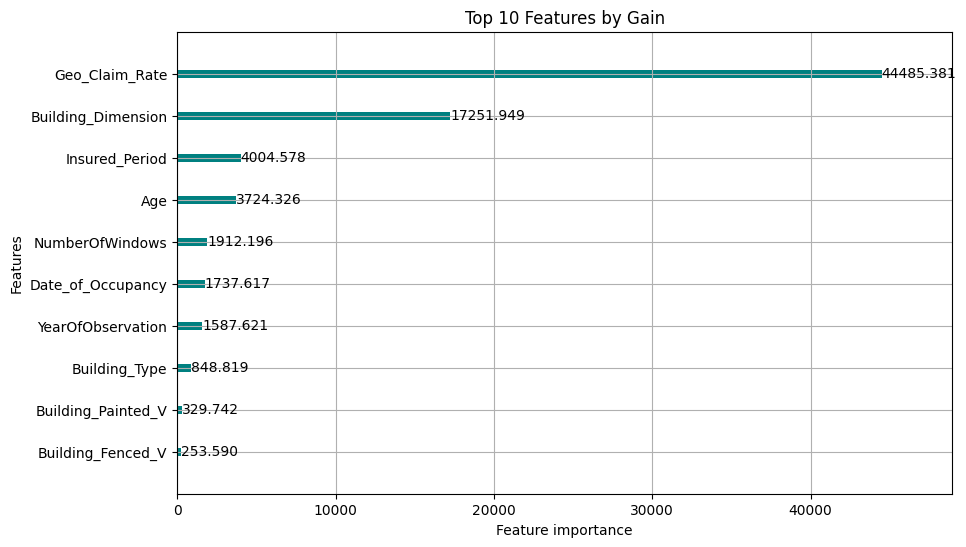

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
lgb.plot_importance(
    tuned_model,
    max_num_features=10,
    importance_type='gain',
    figsize=(10,6),
    color='teal'
)

plt.title('Top 10 Features by Gain')
plt.show()

In [54]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [55]:
from catboost import CatBoostClassifier

In [56]:
cat_model=CatBoostClassifier(
    iterations=500,
    learning_rate=0.03,
    depth=6,
    auto_class_weights='Balanced',
    random_state=42,
    verbose=100
)
cat_model.fit(X_train,y_train,eval_set=[(X_val,y_val)],early_stopping_rounds=50)
y_pred_cat=cat_model.predict(X_val)
y_pred_proba_cat=cat_model.predict_proba(X_val)[:,1]

print("\nCatBoost Accuracy:",accuracy_score(y_val,y_pred_cat))
print("CatBoost AUC:",roc_auc_score(y_val,y_pred_proba_cat))

0:	learn: 0.6802283	test: 0.6804792	best: 0.6804792 (0)	total: 51.6ms	remaining: 25.7s
100:	learn: 0.4798649	test: 0.4985076	best: 0.4985076 (100)	total: 469ms	remaining: 1.85s
200:	learn: 0.4576506	test: 0.4930122	best: 0.4929849 (198)	total: 800ms	remaining: 1.19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4929444052
bestIteration = 201

Shrink model to first 202 iterations.

CatBoost Accuracy: 0.7451117318435754
CatBoost AUC: 0.8333415136939236


In [57]:
lgb_probs=tuned_model.predict_proba(X_val)[:,1]
cat_probs=cat_model.predict_proba(X_val)[:,1]

ensemble_probs=(0.6*cat_probs)+(0.4*lgb_probs)

ensemble_auc=roc_auc_score(y_val,ensemble_probs)
print("Ensemble AUC:",ensemble_auc)

ensemble_preds=(ensemble_probs>=0.5).astype(int)
print("Ensemble Accuracy:",accuracy_score(y_val,ensemble_preds))


Ensemble AUC: 0.8330988296630781
Ensemble Accuracy: 0.7402234636871509


In [58]:
test['Building Dimension'].fillna(test['Building Dimension'].mean(),inplace=True)
test['Insured_Period'].fillna(test['Insured_Period'].mean(),inplace=True)
test['Date_of_Occupancy'].fillna(test['Date_of_Occupancy'].mean(),inplace=True)

/tmp/ipykernel_4928/4172063586.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Building Dimension'].fillna(test['Building Dimension'].mean(),inplace=True)
/tmp/ipykernel_4928/4172063586.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].m

In [59]:
test['Age']=test['YearOfObservation']-test['Date_of_Occupancy']
print(test)

     Customer Id  YearOfObservation  Insured_Period  Residential  \
0         H11920               2013        1.000000            0   
1         H11921               2016        0.997268            0   
2          H9805               2013        0.369863            0   
3          H7493               2014        1.000000            0   
4          H7494               2016        1.000000            0   
...          ...                ...             ...          ...   
3064      H11583               2015        1.000000            0   
3065      H11720               2012        1.000000            0   
3066      H11721               2012        1.000000            0   
3067      H12408               2013        1.000000            0   
3068       H9021               2012        1.000000            0   

     Building_Painted Building_Fenced Garden Settlement  Building Dimension  \
0                   V               N      O          R          300.000000   
1                   V    

In [60]:
test['Garden'].fillna(test['Garden'].mode()[0],inplace=True)
test['Geo_Code'].fillna('Missing',inplace=True)

/tmp/ipykernel_4928/1134467016.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Garden'].fillna(test['Garden'].mode()[0],inplace=True)
/tmp/ipykernel_4928/1134467016.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

In [62]:
test=pd.get_dummies(test,columns=['Building_Painted','Building_Fenced','Garden','Settlement'],drop_first=True)

In [63]:
cols_to_convert=['Building_Painted_V','Building_Fenced_V','Garden_V','Settlement_U']
test[cols_to_convert]=test[cols_to_convert].astype(int)

In [64]:
import numpy as np
test['NumberOfWindows']=test['NumberOfWindows'].replace('.',np.nan)
test['NumberOfWindows']=test['NumberOfWindows'].replace('   .',np.nan)
test['NumberOfWindows']=test['NumberOfWindows'].replace('>=10',10)

In [65]:
test['NumberOfWindows'].fillna(test['NumberOfWindows'].mode()[0],inplace=True)

/tmp/ipykernel_4928/722947387.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['NumberOfWindows'].fillna(test['NumberOfWindows'].mode()[0],inplace=True)


In [70]:
test['NumberOfWindows']=test['NumberOfWindows'].astype(int)

In [71]:
test['Geo_Claim_Rate'] = test['Geo_Code'].map(geo_claim_rates)

In [74]:
X_test=test.drop(columns=['Customer Id','Geo_Code'])
customer_ids=test['Customer Id']

In [75]:
global_mean_claim = y_train.mean()
test['Geo_Claim_Rate'] = test['Geo_Code'].map(geo_claim_rates).fillna(global_mean_claim)

In [76]:
test['Building_Age'] = test['YearOfObservation'] - test['Date_of_Occupancy']
test['Property_Risk_Score'] = (
    test['Building_Painted_V'] +
    test['Building_Fenced_V'] +
    test['Garden_V'] +
    test['Residential']
)
test['Dimension_Type_Interaction'] = test['Building Dimension'] * test['Building_Type']

In [78]:
X_test = pd.DataFrame(index=test.index)
for col in X_train.columns:
    if col in test.columns:
        X_test[col] = pd.to_numeric(test[col], errors='coerce')
    else:
        X_test[col] = 0
X_test = X_test.fillna(0)
test_preds_proba = cat_model.predict_proba(X_test)[:, 1]

In [79]:
submission = pd.DataFrame({
    'Customer Id': customer_ids,
    'Claim': test_preds_proba
})

submission.to_csv('catboost_submission.csv', index=False)
print("Submission file successfully saved as 'catboost_submission.csv'!")

Submission file successfully saved as 'catboost_submission.csv'!
